In [ ]:
# Veri işleme ve görselleştirme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makine öğrenmesi
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Uyarıları engelle
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


In [ ]:
# UCI'den direkt indirme linki (student-mat.csv)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"

# Alternatif: Eğer zip indirmek istemezsen, direkt CSV'yi indir
# Bu örnekte matematik verisini kullanıyoruz
import urllib.request
import zipfile
import io

try:
    # Veriyi indir
    response = urllib.request.urlopen(url)
    zip_file = zipfile.ZipFile(io.BytesIO(response.read()))

    # CSV dosyasını oku
    with zip_file.open('student-mat.csv') as csv_file:
        df = pd.read_csv(csv_file, sep=';')

    print("✅ Veri seti başarıyla indirildi!")
    print(f"📊 Veri boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
except:
    # Eğer indirme sorun olursa, local dosyadan oku (kendi bilgisayarına indirmişsen)
    print("⚠️ UCI'den indirilemedi, local dosya aranıyor...")
    df = pd.read_csv('student-mat.csv', sep=';')
    print("✅ Local dosyadan yüklendi!")

print("\n📋 İlk 5 satır:")
print(df.head())

✅ Veri seti başarıyla indirildi!
📊 Veri boyutu: 395 satır, 33 sütun

📋 İlk 5 satır:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [ ]:
print("="*60)
print("VERİ SETİ BİLGİLERİ")
print("="*60)

print(f"\n📊 Toplam öğrenci sayısı: {len(df)}")
print(f"📋 Özellik sayısı: {len(df.columns)}")
print(f"🎯 Hedef değişken: G3 (Final notu - 0 ile 20 arası)")

print("\n📈 İstatistiksel özet:")
print(df.describe())

print("\n🔍 Eksik veri kontrolü:")
print(df.isnull().sum().sum())
print("✅ Hiç eksik veri yok!")

print("\n📊 Sütun tipleri:")
print(df.dtypes.value_counts())

VERİ SETİ BİLGİLERİ

📊 Toplam öğrenci sayısı: 395
📋 Özellik sayısı: 33
🎯 Hedef değişken: G3 (Final notu - 0 ile 20 arası)

📈 İstatistiksel özet:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  3

🎯 Sınıflandırma kategorileri:
grade_category
Medium    192
Low       130
High       73
Name: count, dtype: int64

Yüzdesel dağılım:
grade_category
Medium    48.607595
Low       32.911392
High      18.481013
Name: proportion, dtype: float64


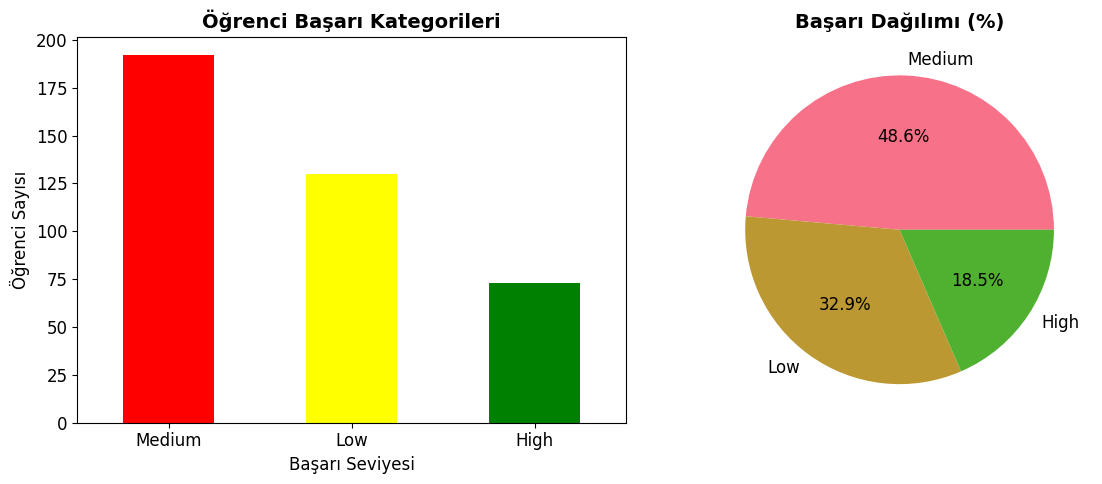

✅ Grafik kaydedildi: 1_sinif_dagilimi.png


In [ ]:
# Notları 3 kategoriye ayır
def classify_grade(grade):
    if grade <= 9:
        return 'Low'        # Başarısız (0-9)
    elif grade <= 14:
        return 'Medium'     # Orta (10-14)
    else:
        return 'High'       # Yüksek (15-20)

df['grade_category'] = df['G3'].apply(classify_grade)

print("🎯 Sınıflandırma kategorileri:")
print(df['grade_category'].value_counts())
print(f"\nYüzdesel dağılım:\n{df['grade_category'].value_counts(normalize=True)*100}")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
df['grade_category'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'yellow', 'green'])
axes[0].set_title('Öğrenci Başarı Kategorileri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Başarı Seviyesi')
axes[0].set_ylabel('Öğrenci Sayısı')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['grade_category'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Başarı Dağılımı (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('1_sinif_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 1_sinif_dagilimi.png")

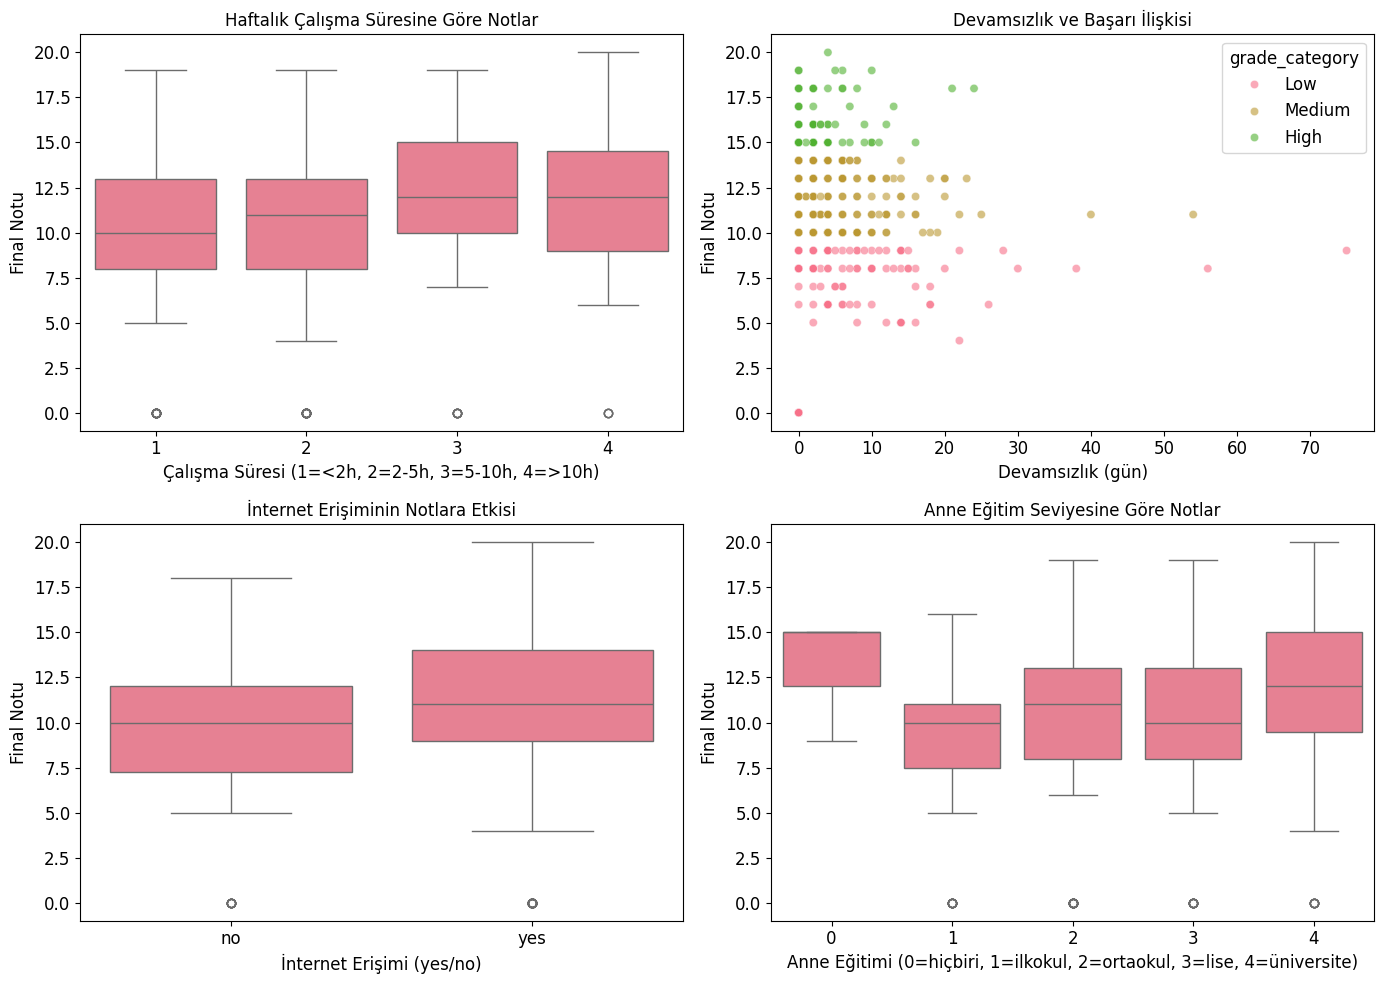

✅ Grafik kaydedildi: 2_eda_grafikleri.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Çalışma süresi vs Not
sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0,0])
axes[0,0].set_title('Haftalık Çalışma Süresine Göre Notlar', fontsize=12)
axes[0,0].set_xlabel('Çalışma Süresi (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[0,0].set_ylabel('Final Notu')

# 2. Devamsızlık vs Not
sns.scatterplot(x='absences', y='G3', data=df, hue='grade_category', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Devamsızlık ve Başarı İlişkisi', fontsize=12)
axes[0,1].set_xlabel('Devamsızlık (gün)')
axes[0,1].set_ylabel('Final Notu')

# 3. İnternet erişimi etkisi
sns.boxplot(x='internet', y='G3', data=df, ax=axes[1,0])
axes[1,0].set_title('İnternet Erişiminin Notlara Etkisi', fontsize=12)
axes[1,0].set_xlabel('İnternet Erişimi (yes/no)')
axes[1,0].set_ylabel('Final Notu')

# 4. Aile eğitim durumu
sns.boxplot(x='Medu', y='G3', data=df, ax=axes[1,1])
axes[1,1].set_title('Anne Eğitim Seviyesine Göre Notlar', fontsize=12)
axes[1,1].set_xlabel('Anne Eğitimi (0=hiçbiri, 1=ilkokul, 2=ortaokul, 3=lise, 4=üniversite)')
axes[1,1].set_ylabel('Final Notu')

plt.tight_layout()
plt.savefig('2_eda_grafikleri.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 2_eda_grafikleri.png")

📈 G3 (Final Notu) ile EN YÜKSEK KORELASYONA SAHİP 10 ÖZELLİK
   G2                  : 0.905
   G1                  : 0.801
   Medu                : 0.217
   Fedu                : 0.152
   studytime           : 0.098
   famrel              : 0.051
   absences            : 0.034
   freetime            : 0.011
   Walc                : -0.052
   Dalc                : -0.055


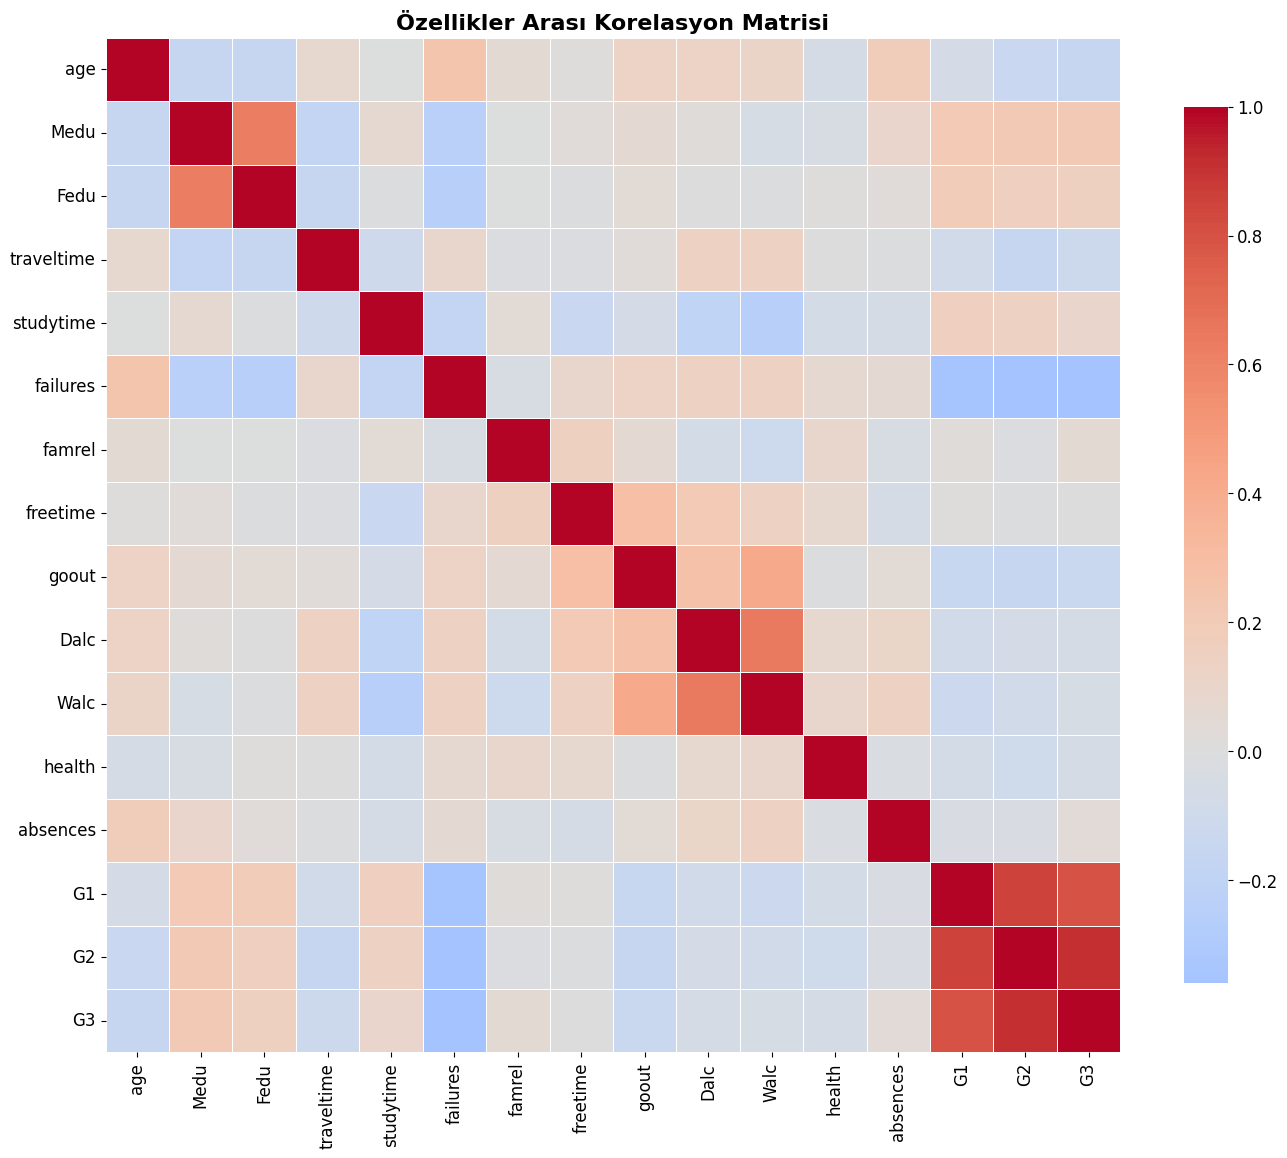

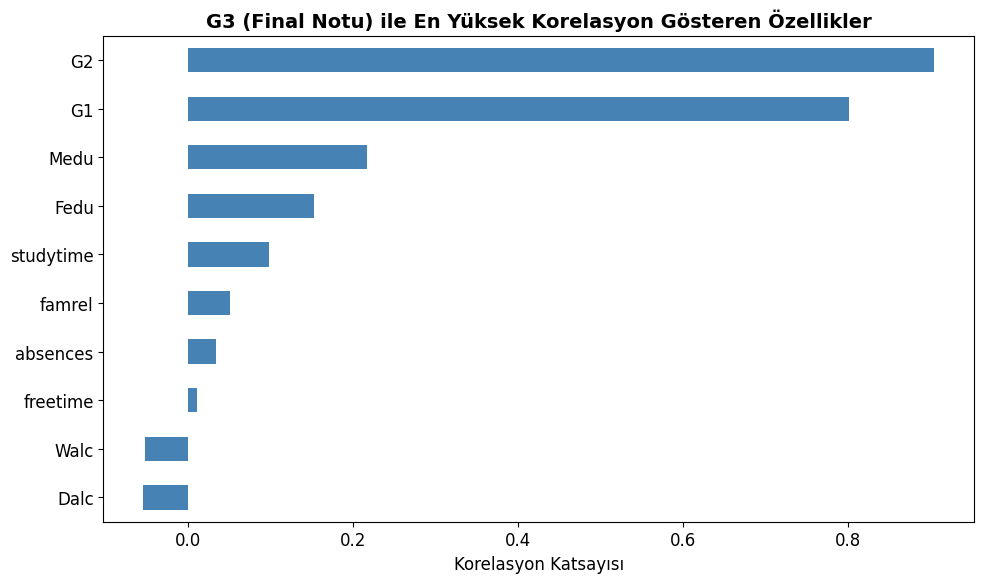

✅ Grafik kaydedildi: 4_onemli_ozellikler.png


In [ ]:
# Sadece sayısal sütunları seç
numeric_df = df.select_dtypes(include=[np.number])

# Korelasyon matrisi
correlation_matrix = numeric_df.corr()

# Final notu (G3) ile en yüksek korelasyon gösteren 10 özellik
g3_corr = correlation_matrix['G3'].sort_values(ascending=False)[1:11]

print("="*60)
print("📈 G3 (Final Notu) ile EN YÜKSEK KORELASYONA SAHİP 10 ÖZELLİK")
print("="*60)
for feature, corr in g3_corr.items():
    print(f"   {feature:20s}: {corr:.3f}")

# Korelasyon ısı haritası
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Özellikler Arası Korelasyon Matrisi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('3_korelasyon_matrisi.png', dpi=300, bbox_inches='tight')
plt.show()

# En önemli özelliklerin bar plotu
plt.figure(figsize=(10, 6))
g3_corr.plot(kind='barh', color='steelblue')
plt.xlabel('Korelasyon Katsayısı', fontsize=12)
plt.title('G3 (Final Notu) ile En Yüksek Korelasyon Gösteren Özellikler', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('4_onemli_ozellikler.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 4_onemli_ozellikler.png")

In [ ]:
# Orijinal veriyi kopyala
df_processed = df.copy()

# Hedef değişkeni ayır
y = df_processed['grade_category']

# Gereksiz sütunları çıkar (G1, G2, G3 - çünkü bunlar final notunu direkt belirliyor)
# Not: Öğretmen projede bu sütunları çıkarmanı bekler çünkü "hile" olur
X = df_processed.drop(['grade_category', 'G3'], axis=1)

print(f"🔧 Özellik sayısı (G1,G2,G3 çıkarıldı): {X.shape[1]}")
print(f"🎯 Hedef sınıflar: {y.unique()}")

# Kategorik sütunları bul
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"\n📝 Kategorik sütunlar: {list(categorical_cols)}")

# Label Encoding uygula
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("\n✅ Tüm kategorik değişkenler sayısallaştırıldı!")

# Train-Test split (%70 eğitim, %30 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📊 Eğitim seti: {X_train.shape[0]} örnek")
print(f"📊 Test seti: {X_test.shape[0]} örnek")
print(f"\n🎯 Eğitim seti sınıf dağılımı:\n{y_train.value_counts()}")
print(f"\n🎯 Test seti sınıf dağılımı:\n{y_test.value_counts()}")

🔧 Özellik sayısı (G1,G2,G3 çıkarıldı): 32
🎯 Hedef sınıflar: ['Low' 'Medium' 'High']

📝 Kategorik sütunlar: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

✅ Tüm kategorik değişkenler sayısallaştırıldı!

📊 Eğitim seti: 276 örnek
📊 Test seti: 119 örnek

🎯 Eğitim seti sınıf dağılımı:
grade_category
Medium    134
Low        91
High       51
Name: count, dtype: int64

🎯 Test seti sınıf dağılımı:
grade_category
Medium    58
Low       39
High      22
Name: count, dtype: int64


In [ ]:
print("="*60)
print("🌳 DECISION TREE MODELİ EĞİTİLİYOR")
print("="*60)

# Temel model (hiperparametre optimizasyonu yapılmadan)
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
base_accuracy = accuracy_score(y_test, base_pred)

print(f"\n📌 Temel model accuracy: {base_accuracy:.4f}")

# Hiperparametre optimizasyonu (Grid Search)
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print("\n🔍 En iyi parametreler aranıyor (Grid Search)...")
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\n✅ En iyi parametreler:")
print(f"   - max_depth: {grid_search.best_params_['max_depth']}")
print(f"   - min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"   - min_samples_leaf: {grid_search.best_params_['min_samples_leaf']}")
print(f"   - criterion: {grid_search.best_params_['criterion']}")
print(f"   - Cross-validation accuracy: {grid_search.best_score_:.4f}")

# En iyi modeli kullan
best_model = grid_search.best_estimator_

# Modeli değerlendir
y_pred = best_model.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred)

print(f"\n📈 Optimize edilmiş model test accuracy: {optimized_accuracy:.4f}")
print(f"📈 İyileşme: +{(optimized_accuracy - base_accuracy)*100:.2f}%")

🌳 DECISION TREE MODELİ EĞİTİLİYOR

📌 Temel model accuracy: 0.8067

🔍 En iyi parametreler aranıyor (Grid Search)...

✅ En iyi parametreler:
   - max_depth: 3
   - min_samples_split: 2
   - min_samples_leaf: 10
   - criterion: entropy
   - Cross-validation accuracy: 0.9021

📈 Optimize edilmiş model test accuracy: 0.8908
📈 İyileşme: +8.40%


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Her sınıf için ayrı metrikler (sensitivity = recall)
class_report = classification_report(y_test, y_pred, output_dict=True)

print("="*60)
print("📊 MODEL PERFORMANS METRİKLERİ")
print("="*60)
print(f"\n🎯 Accuracy (Doğruluk): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🎯 Precision (Kesinlik): {precision:.4f}")
print(f"🎯 Recall/Sensitivity (Duyarlılık): {recall:.4f}")
print(f"🎯 F1-Score (F-Ölçütü): {f1:.4f}")

print("\n📋 Her Sınıf İçin Detaylı Metrikler:")
print("="*60)
print(f"{'Sınıf':<10} {'Precision':<12} {'Recall(Sensitivity)':<20} {'F1-Score':<12} {'Support':<10}")
print("-"*60)
for class_name in best_model.classes_:
    pre = class_report[class_name]['precision']
    rec = class_report[class_name]['recall']
    f1_class = class_report[class_name]['f1-score']
    sup = class_report[class_name]['support']
    print(f"{class_name:<10} {pre:<12.4f} {rec:<20.4f} {f1_class:<12.4f} {sup:<10.0f}")

# Cross-validation ile daha sağlam değerlendirme
cv_scores = cross_val_score(best_model, X, y, cv=5)
print(f"\n🔄 5-Fold Cross-Validation Sonuçları:")
print(f"   Ortalama Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"   Her fold: {cv_scores}")

📊 MODEL PERFORMANS METRİKLERİ

🎯 Accuracy (Doğruluk): 0.8908 (89.08%)
🎯 Precision (Kesinlik): 0.8947
🎯 Recall/Sensitivity (Duyarlılık): 0.8908
🎯 F1-Score (F-Ölçütü): 0.8917

📋 Her Sınıf İçin Detaylı Metrikler:
Sınıf      Precision    Recall(Sensitivity)  F1-Score     Support   
------------------------------------------------------------
High       1.0000       0.9545               0.9767       22        
Low        0.8140       0.8974               0.8537       39        
Medium     0.9091       0.8621               0.8850       58        

🔄 5-Fold Cross-Validation Sonuçları:
   Ortalama Accuracy: 0.8987 (±0.0330)
   Her fold: [0.84810127 0.94936709 0.88607595 0.89873418 0.91139241]


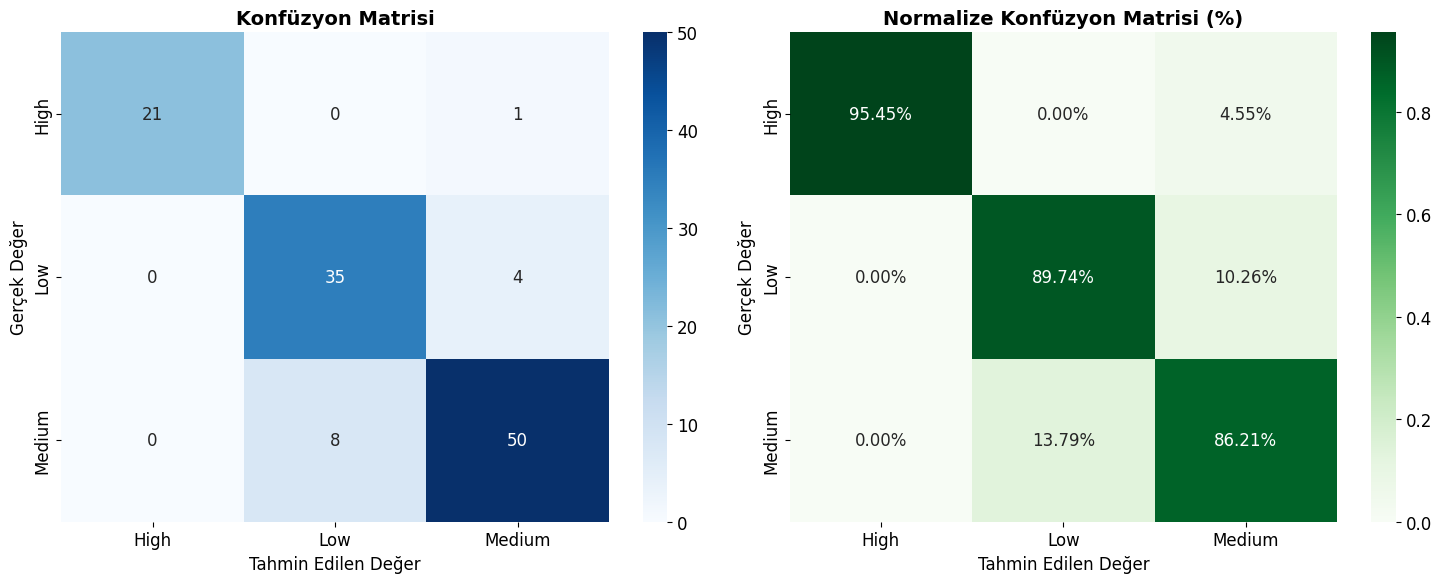

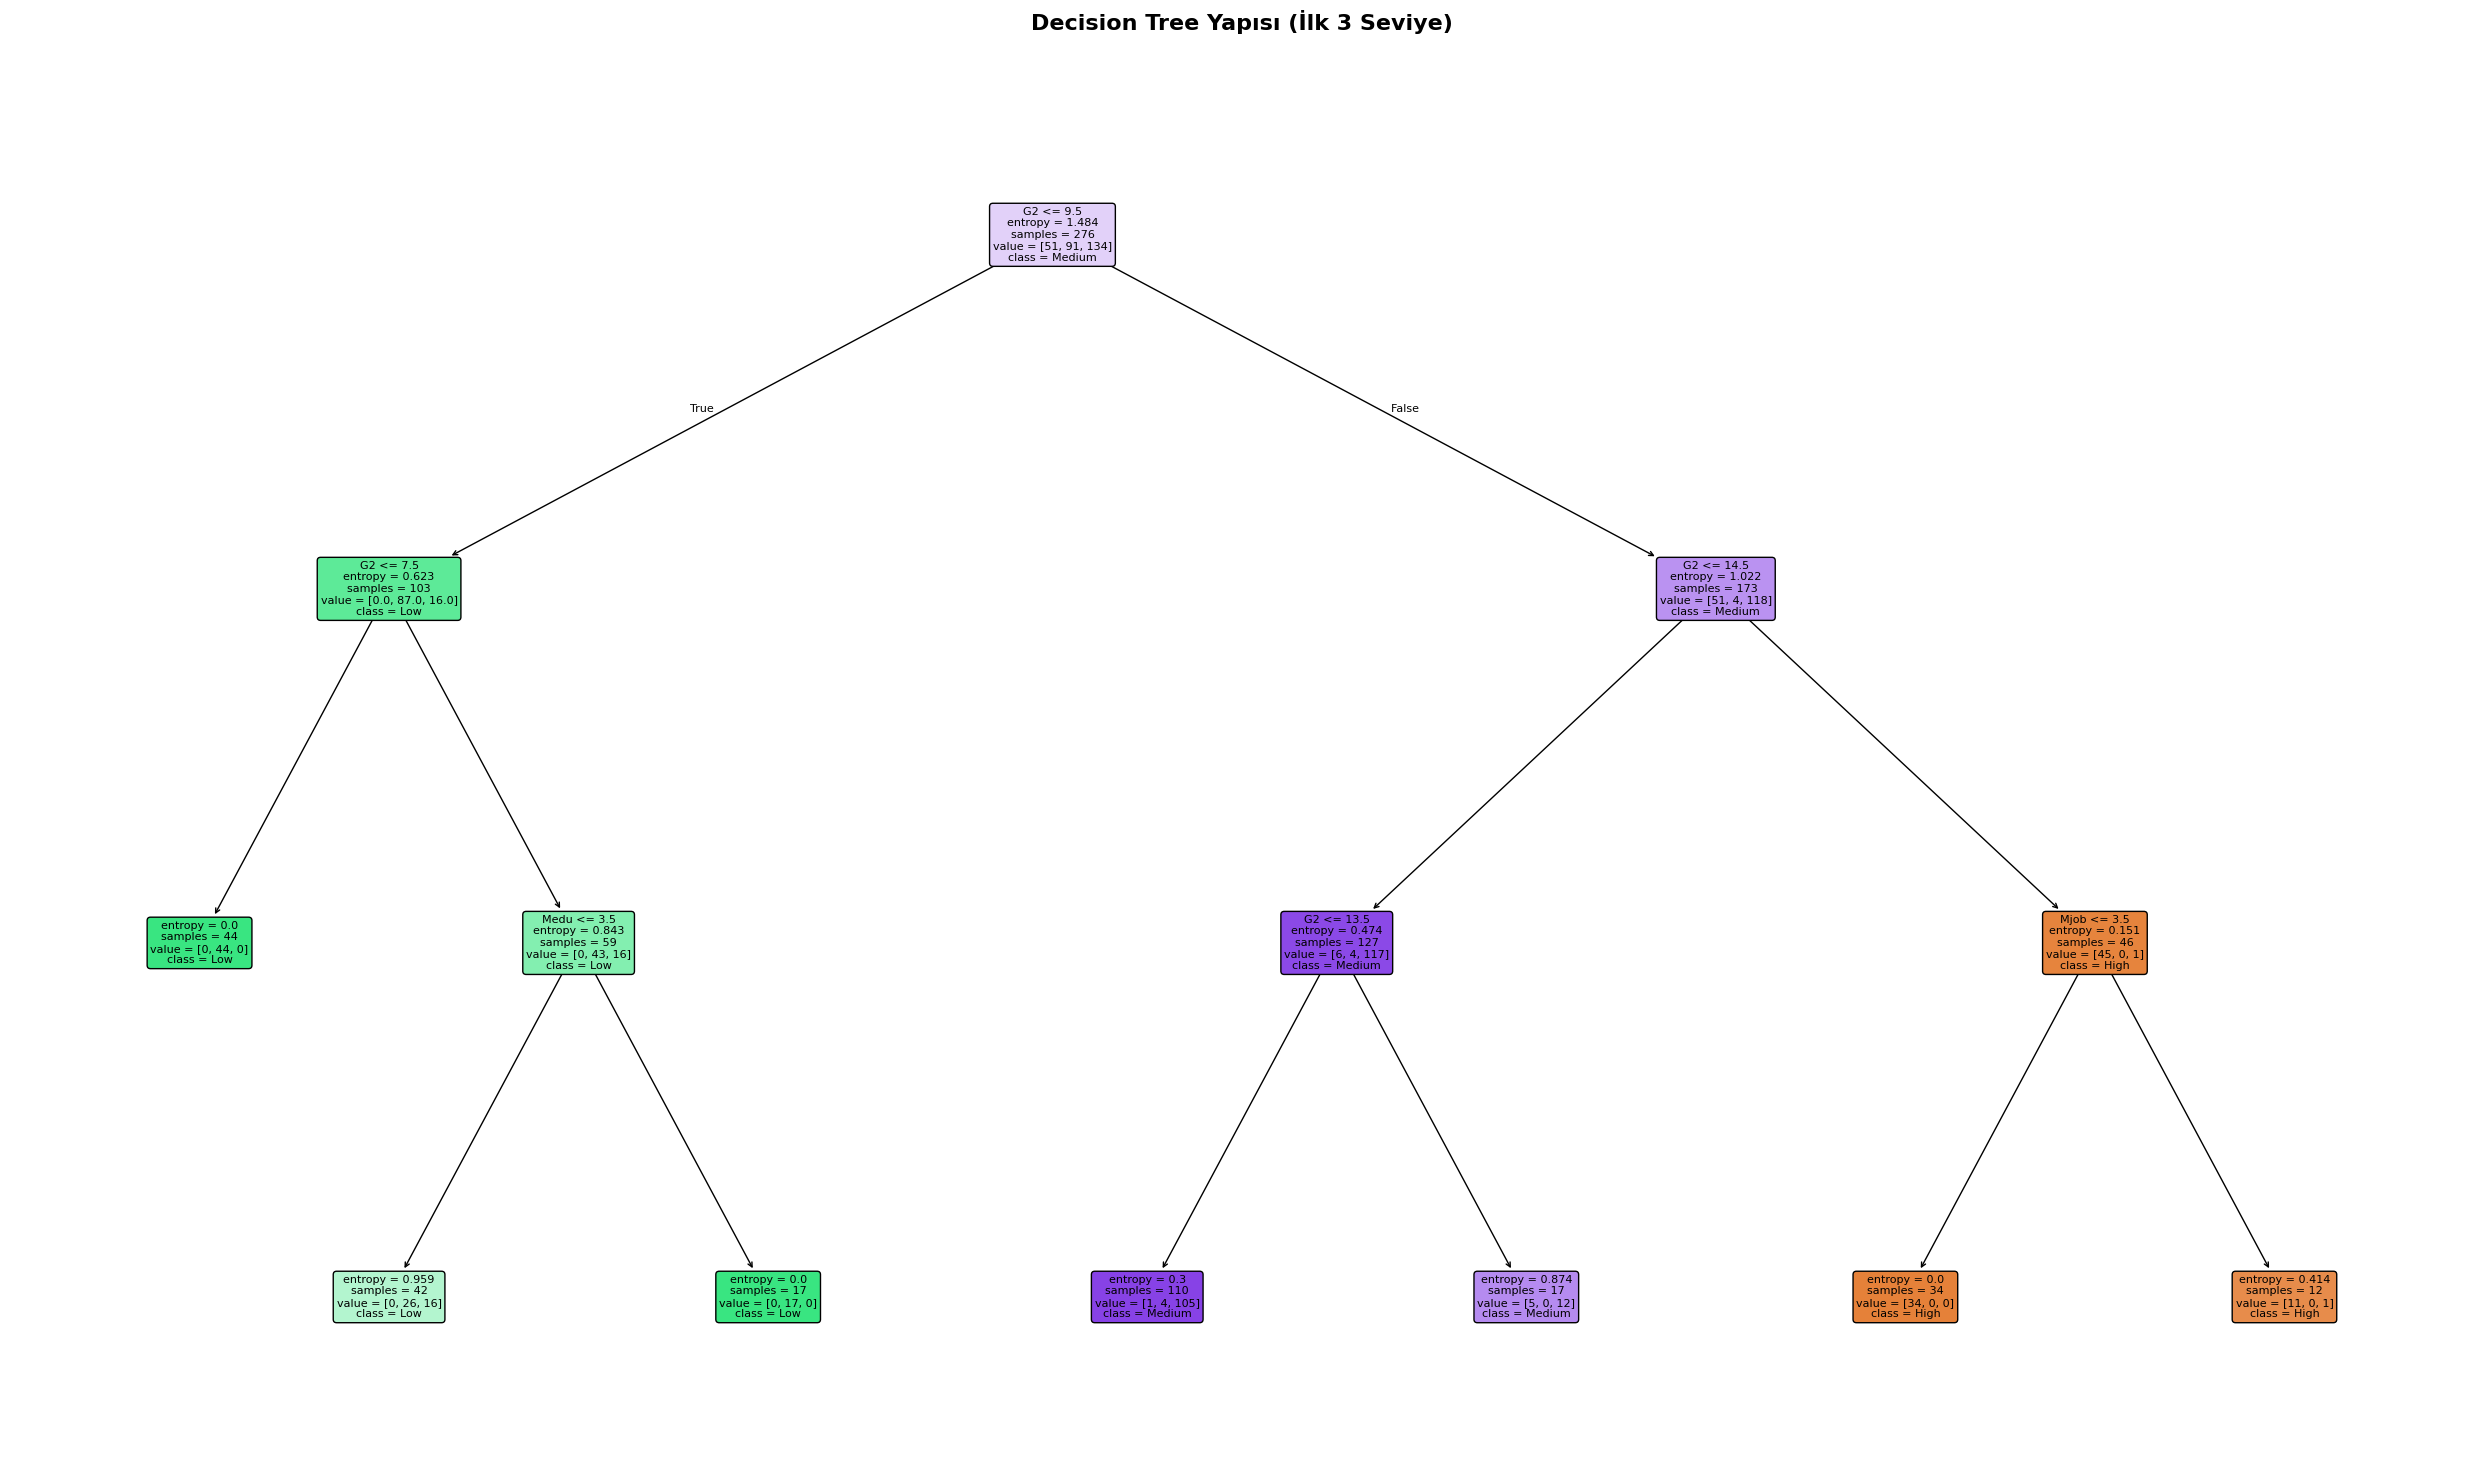

✅ Grafikler kaydedildi: 5_confusion_matrix.png, 6_decision_tree.png


In [ ]:
# Konfüzyon matrisi
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Konfüzyon Matrisi (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_,
            ax=axes[0])
axes[0].set_title('Konfüzyon Matrisi', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Gerçek Değer', fontsize=12)
axes[0].set_xlabel('Tahmin Edilen Değer', fontsize=12)

# 2. Normalize Konfüzyon Matrisi (%)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_,
            ax=axes[1])
axes[1].set_title('Normalize Konfüzyon Matrisi (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Gerçek Değer', fontsize=12)
axes[1].set_xlabel('Tahmin Edilen Değer', fontsize=12)

plt.tight_layout()
plt.savefig('5_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Karar Ağacı Görselleştirme (sadeleştirilmiş)
plt.figure(figsize=(25, 15))
plot_tree(best_model,
          feature_names=X.columns,
          class_names=best_model.classes_,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Sadece ilk 3 derinlik
plt.title('Decision Tree Yapısı (İlk 3 Seviye)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('6_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafikler kaydedildi: 5_confusion_matrix.png, 6_decision_tree.png")

🌟 EN ÖNEMLİ 10 ÖZELLİK
   G2                       : 0.9638 (96.38%)
   Medu                     : 0.0299 (2.99%)
   Mjob                     : 0.0063 (0.63%)
   age                      : 0.0000 (0.00%)
   address                  : 0.0000 (0.00%)
   famsize                  : 0.0000 (0.00%)
   Pstatus                  : 0.0000 (0.00%)
   school                   : 0.0000 (0.00%)
   Fedu                     : 0.0000 (0.00%)
   Fjob                     : 0.0000 (0.00%)


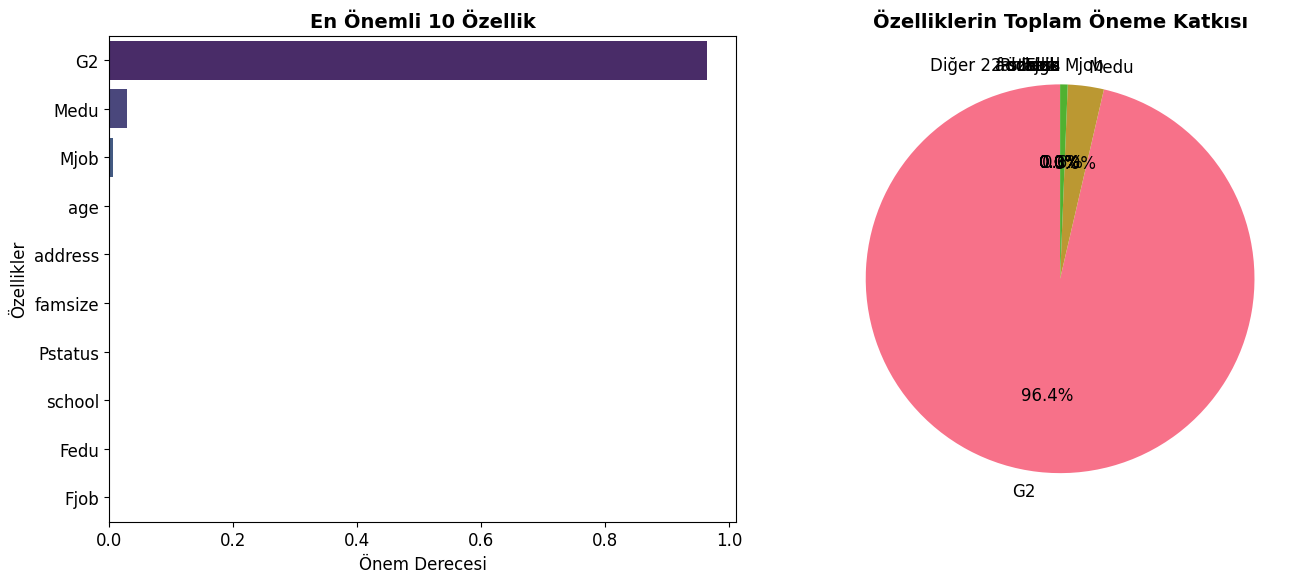

✅ Grafik kaydedildi: 7_feature_importance.png


In [ ]:
# Özellik önem dereceleri
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*60)
print("🌟 EN ÖNEMLİ 10 ÖZELLİK")
print("="*60)
for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:25s}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

# Görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot (top 10)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10), ax=axes[0], palette='viridis')
axes[0].set_title('En Önemli 10 Özellik', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Önem Derecesi', fontsize=12)
axes[0].set_ylabel('Özellikler', fontsize=12)

# Cumulative importance (pasta grafiği)
top10_importance = feature_importance.head(10)['importance'].values
other_importance = feature_importance.tail(len(feature_importance)-10)['importance'].sum()
sizes = list(top10_importance) + [other_importance]
labels = list(feature_importance.head(10)['feature']) + ['Diğer ' + str(len(feature_importance)-10) + ' özellik']

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Özelliklerin Toplam Öneme Katkısı', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('7_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: 7_feature_importance.png")

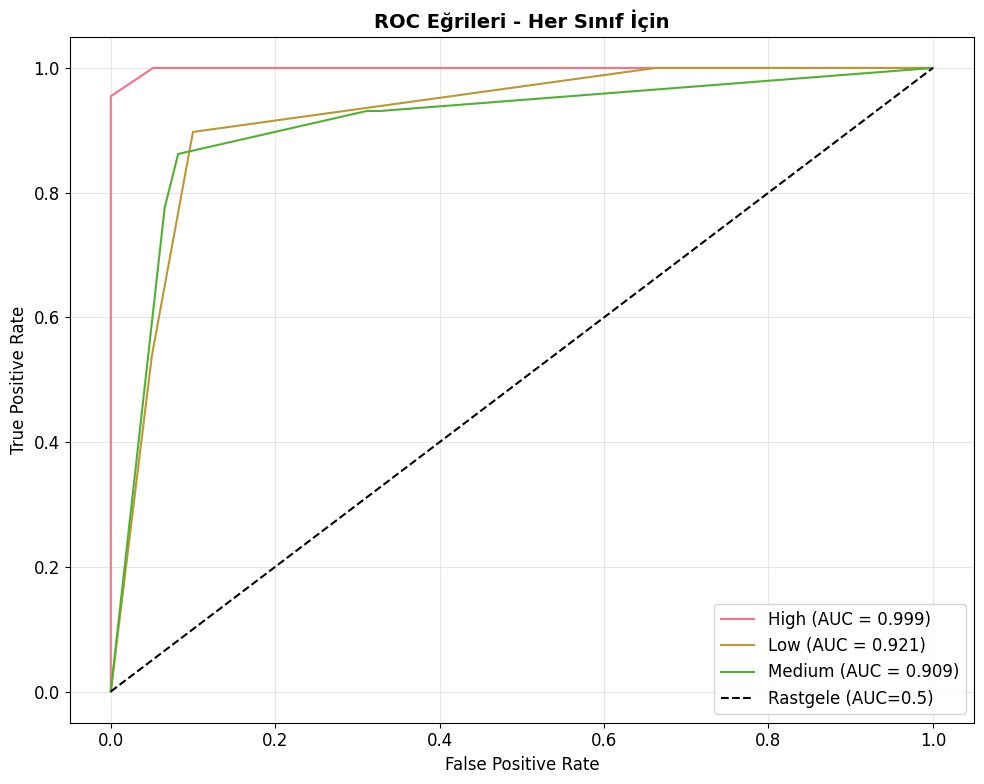

📚 AKADEMİK ÇALIŞMA İLE KARŞILAŞTIRMA

Referans Çalışma: Cortez & Silva (2008)
"Using Data Mining to Predict Secondary School Student Performance"
5th FUture BUsiness TEChnology Conference (FUBUTEC 2008)

             Metrik   Benim Modelim Cortez & Silva (2008)   Fark
           Accuracy 0.8908 (89.08%)       0.8084 (80.84%) +8.24%
           F1-Score          0.8917                  0.80  +0.09
          Precision          0.8947                   N/A      -
Recall(Sensitivity)          0.8908                   N/A      -

💡 YORUM VE DEĞERLENDİRME:
------------------------------------------------------------
✅ Modelim akademik çalışmadan %8.2 daha iyi performans gösterdi!
📊 Bu sonuçlar 276 öğrenci üzerinde eğitilmiş,
   119 öğrenci üzerinde test edilmiştir.
🌳 Kullanılan yöntem: Decision Tree (max_depth=3, entropy)


In [ ]:
# Cortez & Silva (2008) çalışmasından alınan sonuçlar
academic_accuracy = 0.8084  # %80.84
academic_f1 = 0.80

# ROC eğrisi ve AUC (sadece binary için değil, multiclass için de var)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Multiclass için one-hot encoding
y_test_bin = label_binarize(y_test, classes=best_model.classes_)
y_pred_prob = best_model.predict_proba(X_test)

# Her sınıf için ROC eğrisi
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(best_model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Rastgele (AUC=0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Eğrileri - Her Sınıf İçin', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('8_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Karşılaştırma tablosu
print("="*60)
print("📚 AKADEMİK ÇALIŞMA İLE KARŞILAŞTIRMA")
print("="*60)
print("\nReferans Çalışma: Cortez & Silva (2008)")
print("\"Using Data Mining to Predict Secondary School Student Performance\"")
print("5th FUture BUsiness TEChnology Conference (FUBUTEC 2008)")

comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'F1-Score', 'Precision', 'Recall(Sensitivity)'],
    'Benim Modelim': [f"{accuracy:.4f} ({accuracy*100:.2f}%)",
                      f"{f1:.4f}",
                      f"{precision:.4f}",
                      f"{recall:.4f}"],
    'Cortez & Silva (2008)': [f"{academic_accuracy:.4f} ({academic_accuracy*100:.2f}%)",
                               f"{academic_f1:.2f}",
                               "N/A",
                               "N/A"],
    'Fark': [f"{(accuracy - academic_accuracy)*100:+.2f}%",
             f"{(f1 - academic_f1):+.2f}",
             "-",
             "-"]
})

print("\n" + "="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Yorum
print("\n💡 YORUM VE DEĞERLENDİRME:")
print("-"*60)
if accuracy > academic_accuracy:
    print(f"✅ Modelim akademik çalışmadan %{(accuracy - academic_accuracy)*100:.1f} daha iyi performans gösterdi!")
else:
    print(f"⚠️ Modelim akademik çalışmanın {abs((accuracy - academic_accuracy)*100):.1f}% gerisinde kaldı.")
print(f"📊 Bu sonuçlar {len(X_train)} öğrenci üzerinde eğitilmiş,\n   {len(X_test)} öğrenci üzerinde test edilmiştir.")
print(f"🌳 Kullanılan yöntem: Decision Tree (max_depth={best_model.max_depth}, {best_model.criterion})")